# [Open in Google Colab](https://colab.research.google.com/github/Jechen00/segformer-pytorch/blob/main/notebooks/mit_b1_pretraining.ipynb)

# **Note**: The logs are from training on an A100 GPU

# 0) Imports



In [ ]:
import torch
from torch import nn
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.optim import AdamW

import sys, os
import random
from pathlib import Path
from IPython.display import clear_output, display

import warnings
warnings.filterwarnings('ignore', message = 'Corrupt EXIF data.*')


# -----------------------------------------------------------
os.chdir('/content') # Ensure in content directory

# Check if running in Google Colab
try:
    import google.colab
    print('\033[1m[ALERT]\033[0m Running in Google Colab.')
    IN_COLAB = True
    REPO_ROOT = Path('./segformer-pytorch')

except ImportError:
    print('\033[1m[ALERT]\033[0m Running in segformer-pytorch repository.')
    IN_COLAB = False
    REPO_ROOT = Path('../..')

# Clone repo if it doesn't exist
if IN_COLAB and (not os.path.exists(REPO_ROOT)):
    print('\033[1m[ALERT]\033[0m Repository not found. Cloning segformer-pytorch from GitHub...')
    !git clone https://github.com/Jechen00/segformer-pytorch.git


# -----------------------------------------------------------
# Import repo modules
sys.path.append(str(REPO_ROOT))

from src.models import MiTClassification

from src.data_setup.transforms.pipelines import get_transforms
from src.data_setup.dataloader_utils import build_dataloader
from src.data_setup.datasets import MiniImageNetDataset

from src.metrics import ClassificationMetrics
from src.metrics.postprocess import MetricSpec

from src.engine.trainer_settings import EvalSettings, SchedulerSettings, PerformanceSettings, SaveSettings
from src.engine.measure_policy import MeasurePolicy
from src.engine.trainer import ModelTrainer

from src.utils import ml_utils
from src.engine.checkpoint import separate_checkpoint
from src.visualize.plot_results import plot_loss, plot_summary_metrics, plot_class_metrics
from src.visualize import plot_preds

# -----------------------------------------------------------
clear_output(wait = True) # Clear cluttered output after setup

ml_utils.set_seed(0) # Set seed for reproducibility
DEVICE = ml_utils.get_device() # Computation device

print(f'\033[1mCPU count:\033[0m {os.cpu_count()}')
print(f'\033[1mDevice:\033[0m {DEVICE}')

CPU count: 12
Device: cuda


# 1) Introduction

The original SegFormer model pretrains its Mixed Transformer (MiT) backbones on an image classification task using ImageNet-1k. When training the full SegFormer model for the main segmentation task, these pretained weights provide the MiT backbone with a strong starting point that can already extract meaningful features/patterns from images (e.g. edges and textures).

<br>

In this Google Colab example, we will **pretrain a MiT backbone** on a small subset of ImageNet-1k known as [**Mini-ImageNet**](https://huggingface.co/datasets/timm/mini-imagenet). This dataset contains only 100 out of the 1000 classes from ImageNet and has fewer examples per class, making it more practical to train on for resource-limited environments.

The Mini-ImageNet **training split** contains 500 images per class (50,000 total), while the **validation split** contains 100 images per class (10,000 total).


---



# 2) Mini-ImageNet Dataset

## 2.1) Set Up Transforms

For both **training and validation**, all images are resized to **512x512** using a **letterbox** transform that preserves the aspect ratios.

<br>

For **training only**, we also use a simple pipeline that first applies geometric augmentations and then photometric augmentations.

The **geometric augmentations** include:
  - Random horizontal flip
  - Random affine (rotate, translate, scale)

The **photometric augmentations** include:
  - Color jitter
  - Random grayscale conversion
  - Random apply Gaussian blur or sharpening


<br>

Note that **tensor conversion** and **normalization** are not included in these transform pipelines because the dataset provides optional built-in versions that are applied after the user-provided transforms.

The transform pipelines for training and validation are obtained from `transforms.get_transforms`.


In [ ]:
# Resizing values
IMG_SIZE = (512, 512)
SIZING_MODE = 'letterbox'

# Fill value for geo transforms
IMG_FILL = 114

# ----------------------------------------------------------------
# Training transforms (resizing + augmentations)
train_transforms = get_transforms(
    tf_types = ['geo', 'phot'],
    size = IMG_SIZE,
    sizing_mode = SIZING_MODE,
    img_fill = IMG_FILL,
    include_geo_augs = True # Include geo augmentations
)

# Validation transforms (resizing only)
# This is just a resizing transform because `tf_types='geo'` and `include_geo_augs=False`
val_transforms = get_transforms(
    tf_types = 'geo',
    size = IMG_SIZE,
    sizing_mode = SIZING_MODE,
    img_fill = IMG_FILL,
    include_geo_augs = False # Exclude geo augmentations
)

## 2.2) Set Up Datasets

The training and validation splits for Mini-ImageNet can both be obtained by creating a `datasets.MiniImageNetDataset` instance.

<br>

This dataset instance has optional built-in **tensor conversion** (`to_tensor = True`) and **normalization** (`norm_mean` and `norm_std`) that is applied after any user-provided transforms.

The **transform pipeline** in the `MiniImageNetDataset` instance can be accessed using the `.transform_pipeline` attribute and is ordered like so:
  1. User-provided transforms
  2. Optional image tensor conversion (if `to_tensor=True`)
  3. Optional float32 conversion and scaling (if `to_tensor=True`)
  4. Normalization (if `norm_mean` and `norm_std` are provided)

<br>

A fully **processed sample** from the dataset can be obtained by directly indexing it (e.g. `dataset[index]`). This sample has been transformed and is returned as a dictionary containing 2 keys:
  - **image** (`Union[torch.Tensor, Image.Image]`): Sample image after it has passed through the transform pipeline.
  - **label** (`Union[torch.Tensor, int]`): Target index label for the image.

To access a **sample before dataset transforms**, we can use the `.get_base_item(index)` method of the `MiniImageNetDataset` instance. This still returns a dictionary with an `image` and `label` key.

In [ ]:
DATA_ROOT = REPO_ROOT / 'data'

# Convert all samples to tensors
TO_TENSOR = True

# Normalize with ImageNet stats after tensor conversion
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD = [0.229, 0.224, 0.225]


# ----------------------------------------------------------------
train_dataset = MiniImageNetDataset(
    root = DATA_ROOT,
    split = 'train',
    transforms = train_transforms,
    to_tensor = TO_TENSOR,
    norm_mean = NORM_MEAN,
    norm_std = NORM_STD
)

val_dataset = MiniImageNetDataset(
    root = DATA_ROOT,
    split = 'val',
    transforms = val_transforms,
    to_tensor = TO_TENSOR,
    norm_mean = NORM_MEAN,
    norm_std = NORM_STD
)


# ----------------------------------------------------------------
# Clear cluttered output
clear_output(wait = True)

# Print class names
NUM_CLASSES = len(train_dataset.class_names)
print(f'Classes: {train_dataset.class_names}')

Classes: ['house_finch', 'robin', 'triceratops', 'green_mamba', 'harvestman', 'toucan', 'goose', 'jellyfish', 'nematode', 'king_crab', 'dugong', 'Walker_hound', 'Ibizan_hound', 'Saluki', 'golden_retriever', 'Gordon_setter', 'komondor', 'boxer', 'Tibetan_mastiff', 'French_bulldog', 'malamute', 'dalmatian', 'Newfoundland', 'miniature_poodle', 'white_wolf', 'African_hunting_dog', 'Arctic_fox', 'lion', 'meerkat', 'ladybug', 'rhinoceros_beetle', 'ant', 'black-footed_ferret', 'three-toed_sloth', 'rock_beauty', 'aircraft_carrier', 'ashcan', 'barrel', 'beer_bottle', 'bookshop', 'cannon', 'carousel', 'carton', 'catamaran', 'chime', 'clog', 'cocktail_shaker', 'combination_lock', 'crate', 'cuirass', 'dishrag', 'dome', 'electric_guitar', 'file', 'fire_screen', 'frying_pan', 'garbage_truck', 'hair_slide', 'holster', 'horizontal_bar', 'hourglass', 'iPod', 'lipstick', 'miniskirt', 'missile', 'mixing_bowl', 'oboe', 'organ', 'parallel_bars', 'pencil_box', 'photocopier', 'poncho', 'prayer_rug', 'reel', 

## 2.3) Set Up Dataloaders

The function `dataloader_utils.build_dataloaders` can be used to create dataloaders for the train and validation datasets. Since this example is ran on an A100, the dataloaders will use a **batch size** of 64 and multi-process data loading with 10 **workers**.

A batch from these dataloaders is returned as a dictionary with 2 keys:

- **image** (`torch.Tensor`): Batch of images of shape `(batch_size, channels, height, width)`

- **label** (`torch.Tensor`): Batch of labels of shape `(batch_size,)`

In [ ]:
BATCH_SIZE = 64
NUM_WORKERS = 10


# ----------------------------------------------------------------
train_loader = build_dataloader(
    dataset = train_dataset,
    split = 'train',
    batch_size = BATCH_SIZE,
    num_workers = NUM_WORKERS,
    device = DEVICE
)

val_loader = build_dataloader(
    dataset = val_dataset,
    split = 'val',
    batch_size = BATCH_SIZE,
    num_workers = NUM_WORKERS,
    device = DEVICE
)


# ----------------------------------------------------------------
# Print sample shapes
batched_samp = next(iter(train_loader))

print(f"Batched Image Shape: {batched_samp['image'].shape}")
print(f"Batched Label Shape: {batched_samp['label'].shape}")

Batched Image Shape: torch.Size([64, 3, 512, 512])
Batched Label Shape: torch.Size([64])


# 3) Model

The version of the backbone we will be pretraining is **MiT-B1**. To adapt this backbone for image classification tasks, we take the feature maps from the final encoder stage and pass them through a simple **global average pooling (GAP)** classification head.

This model is instantiated as `models.MiTClassification`.

In [ ]:
# MiT-B1 Config
mit_cfg = {
    'in_channels': 3,
    'feature_dims': (64, 128, 320, 512),
    'patch_sizes': (7, 3, 3, 3),
    'strides': (4, 2, 2, 2),
    'num_blks': (2, 2, 2, 2),
    'num_heads': (1, 2, 5, 8),
    'reduce_ratios': (8, 4, 2, 1),
    'hid_dims': (512, 1024, 1280, 2048),
    'enc_activations': None,  # Defaults to GELU
    'ffn_dropout_probs': 0.05,
    'attn_dropout_probs': 0.05,
    'max_sdepth_prob': 0.1
}

model = MiTClassification.from_mit_config(
    mit_config = mit_cfg,
    num_classes = NUM_CLASSES
)


# ----------------------------------------------------------------
# Print number of parameters
total_params = sum(p.numel() for p in model.parameters())
print('Total Params:', total_params)

Total Params: 13541156


# 4) Loss and Optimizer

The loss function we use is the **cross-entropy loss** (`nn.CrossEntropyLoss`).

We include label smoothing in this loss for additional regularization.

<br>

The optimizer we use is **AdamW** (`optim.AdamW`), with a starting learning rate of `2e-4`. The beta and weight decay values are kept at their default `PyTorch` values.

In [ ]:
# Loss function
loss_fn = nn.CrossEntropyLoss(reduction = 'mean', label_smoothing = 0.05)


# Optimizer
optimizer = AdamW(
    model.parameters(),
    lr = 2e-4,
    betas = (0.9, 0.999),
    weight_decay = 0.01
)

# 5) (Optional) Learning Rate Scheduler

We use a **cosine annealing learning rate scheduler** (`optim.lr_scheduler.CosineAnnealingLR`) to gradually reduce the learning rate of the optimizer throughout training. This allows the optimizer to more easily fine tune the model weights in the later stages of training.

The minimum learning rate is set to `5e-6` and the scheduler should be stepped/updated after every optimizer step (`step_freq = 'optim_step'`) rather than only at the end of each epoch.

<br>

To pass both the scheduler and the step frequency information to the model trainer, we must instantiate a `trainer_settings.SchedulerSettings` dataclass object.


In [ ]:
NUM_EPOCHS = 50
STEP_FREQ = 'optim_step'


# ----------------------------------------------------------------
if STEP_FREQ == 'epoch':
    T_max = NUM_EPOCHS
else:
    T_max = NUM_EPOCHS * len(train_loader) # Multiply by number of iterations/batches per epoch

# Create scheduler
scheduler = CosineAnnealingLR(
    optimizer,
    T_max = T_max,
    eta_min = 5e-6
)

# Create dataclass
sched_settings = SchedulerSettings(
    scheduler = scheduler,
    step_freq = STEP_FREQ
)

# 6) (Optional) Evaluation Metrics

Evaluation metrics must be structured as a dictionary mapping task/metric names to **metric objects** that implement a `metrics.Metric` protocol. Briefly, a metric object provides a `.update()` method (for accumulating target-prediction data) and a `.compute()` method (for computing the metrics), similar to the objects in from `TorchMetrics`.

For this example, we only use the metric object `metrics.ClassificationMetrics`, which computes the following metrics: **accuracy, precision, recall, F1-score**.

Specifically, it outputs a dictionary containing:

- **accuracy** (`torch.Tensor`): Overall accuracy across all classes.
- **recall** (`torch.Tensor`): Per-class recall tensor of shape `(num_classes,)`.
- **mean_recall** (`torch.Tensor`): Mean recall across classes with at least one target or prediction.
- **precision** (`torch.Tensor`): Per-class precision tensor of shape `(num_classes,)`.
- **mean_precision** (`torch.Tensor`): Mean precision across classes with at least one target or prediction.
- **f1_score** (`torch.Tensor`): Per-class F1-score tensor of shape `(num_classes,)`.
- **mean_f1_score** (`torch.Tensor`): Mean F1-score across valid classes.
- **tot_count** (`torch.Tensor`): Total number of non-ignored target elements.


<br>


During training, each epoch will iterate through the `metrics` dictionary and call the `.compute()` method. This produces a results dictionary mapping the task/metric names to the corresponding `.compute()` outputs.

We can optionally **log certain metrics** from this results dictionary. This requires defining a `log_metric_specs` dictionary that maps metric names to metric specification (`metrics.MetricSpec`) objects.

A `MetricSpec` is a dataclass that specifies how a metric should be extracted and processed:
  - **key_path**: Dot-separated key path to extract a metric from the results dictionary (e.g. `cls.accuracy`).
  - **class_idxs** (optional): Class indices used to subset tensors in the extracted metric.
  - **agg** (optional): Aggregation method applied to tensors after extracting
  - **units** (optional): Unit associated with the metric.

One requirement is that each metric specification must yield a scalar value (e.g. mean recall, mean precision, mean F1-score).

<br>

To pass the `metrics` and `log_metric_specs` dictionaries to the model trainer, we must instantiate a `trainer_settings.EvalSettings` object. This also allows us to specify how frequently evaluation metrics are computed through the `eval_interval` argument.

In [ ]:
# Evaluation metrics for validation
metrics = {'cls': ClassificationMetrics(num_classes = NUM_CLASSES)}

# Evaluation Settings
log_metric_specs = {
    'Accuracy': MetricSpec(key_path = 'cls.accuracy'),
    'Recall (Mean)': MetricSpec(key_path = 'cls.mean_recall'),
    'Precision (Mean)': MetricSpec(key_path = 'cls.mean_precision'),
    'F1-score (Mean)': MetricSpec(key_path = 'cls.mean_f1_score'),
    'Recall (Min)': MetricSpec(key_path = 'cls.recall', agg = 'min'),
    'Precision (Min)': MetricSpec(key_path = 'cls.precision', agg = 'min'),
    'F1-score (Min)': MetricSpec(key_path = 'cls.f1_score', agg = 'min')
}

eval_settings = EvalSettings(
    metrics = metrics,
    eval_interval = 1, # Evaluate every epoch
    log_metric_specs = log_metric_specs
)

# 7) (Optional) Measure Policy

During training, decisions such as **saving a best model** and performing **early stopping** can be made based on the improvement of a designated primary measure (a loss or metric). We call this decision making a "measure policy" and is configured in the model trainer through a `measure_policy.MeasurePolicy` object.

The primary measure used in this example is the **mean F1-score**, computed across all 100 classes of the Mini-ImageNet dataset. This metric is computed by `metrics.ClassificationMetrics` and can be extracted from the metric result dictionary using the key path `cls.mean_f1_score`.

The best model is defined as the model containing the weights that maximize the mean F1-score during training. Additionally, early stopping is performed when the mean F1-score does not significantly increase after 5 evaluation epochs.

In [ ]:
# Measure policy (for early stopping + best score tracking)
measure_policy = MeasurePolicy(
    measure_type = 'metric',
    metric_spec = MetricSpec(key_path = 'cls.mean_f1_score'),
    mode = 'max',
    min_delta = 1e-3,
    patience = 5 # This is number of eval intervals, not epochs
)

# 8) (Optional) Other Settings/Configs

Additional settings-related dataclasses that can be configured in the model trainer are `trainer_settings.PerformanceSettings` and `trainer_settings.SaveSettings`.

<br>

`PerformanceSettings` configures the settings for training performance. This includes the computation device (e.g. CPU, MPS, CUDA), memory format (contiguous or channels last), and the use of Automatic Mixed Precision (AMP). The last option is for CUDA devices only.

<br>

`SaveSettings` configures the saving behavior of the model trainer, including the paths for saving the training checkpoint (at the end of each epoch) and the best model (after each measure improvement). If one or more of these save paths are not provided, the corresponding saving process will not be performed. Also note that in order for a best model to be saved, a `MeasurePolicy` must be provided in the model trainer.

In [ ]:
# Performance Settings
perf_settings = PerformanceSettings(
    device = DEVICE,
    memory_format = torch.channels_last,
    use_amp = True,
    amp_dtype = torch.float16
)


# Save Settings
SAVE_DIR = REPO_ROOT / 'backbone_pretrain/mini_imagenet/mit_b1'

save_settings = SaveSettings(
    save_dir = SAVE_DIR,
    ckpt_name = 'checkpoint.pth',
    best_model_name = 'best_cls_mod.pth',
    ignore_exists = True # If True, any files prior to training will be overwritten
)

# 9) Model Trainer

## 9.1) Creating the `ModelTrainer` object

To start training, we must instantiate a `trainer.ModelTrainer`.

The **required arguments** are:
  - **model** (`nn.Module`): The model to train.
  - **train_loader** (`utils.data.DataLoader`): Dataloader for the training dataset.
  - **val_loader** (`utils.data.DataLoader`): Dataloader for the validation dataset.
  - **targ_key** (`str`): Key to access target tensor from each batch returned by the dataloaders.
  - **loss_fn** (`nn.Module`): Loss function that accepts model logits and targets.
  - **optimizer** (`optim.Optimizer`): Optimizer used to update `model` weights.

The **optional arguments** are:
  - **sched_settings** (`SchedulerSettings`): Settings for the learning rate scheduler. If not provided, no scheduler is used.
  - **eval_settings** (`EvalSettings`): Settings for validation metric evaluations. If not provided, validation metrics are not computed.
  - **measure_policy** (`MeasurePolicy`): Measure policy that designates a measure to use for best model saving and early stopping. If not provided, these decision processes are disabled.
  - **save_settings** (`SaveSettings`): Settings for saving the training checkpoint and possibly the best model (requires `measure_policy` to be provided).
  - **perf_settings** (`PerformanceSettings`): Settings for training performance. If not provided, a default `PerformanceSettings()` instance is used, which trains on CPU with contiguous format and doesn't use AMP.

In [ ]:
model_trainer = ModelTrainer(
    model = model,
    train_loader = train_loader,
    val_loader = val_loader,
    targ_key = 'label', # Targets are accessed from dataloaders using 'label' key
    loss_fn = loss_fn,
    optimizer = optimizer,

    sched_settings = sched_settings,
    eval_settings = eval_settings,
    measure_policy = measure_policy,

    perf_settings = perf_settings,
    save_settings = save_settings
)

[NOTE] Training checkpoint will be saved at: segformer-pytorch/backbone_pretrain/mini_imagenet/mit_b1/checkpoint.pth
[NOTE] Best model will be saved at: segformer-pytorch/backbone_pretrain/mini_imagenet/mit_b1/best_cls_mod.pth



## 9.2) (Optional) Resume from Previous Checkpoint


We can optionally resume from a previous checkpoint using the `.load_checkpoint()` method of `ModelTrainer`. This takes in the argument `resume_path` for the file path to the saved checkpoint that we are resuming from.

In [ ]:
# resume_path = save_settings.ckpt_path
# model_trainer.load_checkpoint(resume_path)

## 9.3) Start Training

To start training with the model trainer, use the `.train(num_epochs)` method.

After training finishes, this method returns 2 history objects:
  - **train_history** (`logging.history.TrainHistory`): Training-phase history containing the epoch losses.
  - **val_history** (`logging.history.ValHistory`): Validation-phase history containing the epoch losses and optional metric values (computed per evaluation interval/epoch).


For both `train_history` and `val_history`, the loss-related attributes are:
  - `loss.values`: List of recorded loss values.
  - `loss.epochs`: List of epochs corresponding to `loss.values`.

For `val_history`, the metric-related attributes are:
  - `metrics.values`: Dictionary with lists of recorded metric values.
  - `metrics.epochs`: Lists of epochs corresponding to `metrics.values`.

Note that the metric-related attributes of `val_history` will be empty if metrics are not computed during training (e.g. if `eval_settings` is not provided when initializing `ModelTrainer`).

In [ ]:
train_history, val_history = model_trainer.train(NUM_EPOCHS)

[NOTE] Checkpoints will be saved at: segformer-pytorch/backbone_pretrain/mini_imagenet/mit_b1/checkpoint.pth
[NOTE] Best model will be saved at: segformer-pytorch/backbone_pretrain/mini_imagenet/mit_b1/best_cls_mod.pth



/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: Flash Attention defaults to a non-deterministic algorithm. To explicitly enable determinism call torch.use_deterministic_algorithms(True, warn_only=False). (Triggered internally at /pytorch/aten/src/ATen/native/transformers/cuda/attention_backward.cu:124.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


============================================= EPOCH   0 ============================================
----------------------------------------------------------------------------------------------------
| [LOSS]                                                                                           |
| train (mean):           4.3427 | val (mean):             4.0691 |                                |
----------------------------------------------------------------------------------------------------
| [TIME]                                                                                           |
| train:            325.3048 sec | val:               26.3063 sec |                                |

============================================= EPOCH   1 ============================================
----------------------------------------------------------------------------------------------------
| [LOSS]                                                                                  

# 10) Load Best Model

The file path used to save the best-model state dictionary (weights) can be accessed using the `best_model_path` of the `SaveSettings` object.

The saved state dictionary can be loaded with the `torch.load()` function from `PyTorch`. If necessary to load the state dictinary onto a device different from training/saving, use the `map_location` argument.

The state dictionary can then be loaded into the model using the `.load_state_dict()` method that is typically available for all `PyTorch` models.

In [ ]:
best_model_path = save_settings.best_model_path
best_state_dict = torch.load(best_model_path)

best_model = MiTClassification.from_mit_config(
    mit_config = mit_cfg,
    num_classes = NUM_CLASSES
)
best_model.load_state_dict(best_state_dict)

# Save MiT backbone
best_model.save_mit_backbone(SAVE_DIR / 'best_backbone.pth')

# Print best score (from the measure policy)
val_history.best_score

{'value': 0.7527325749397278,
 'epoch': 49,
 'measure_info': {'measure_type': 'metric',
  'key_path': 'cls.mean_f1_score',
  'class_idxs': None,
  'agg': None,
  'unit': None}}

# 11) Plot Result Curves

## 11.1) Plot Loss Curves

**Loss curves** (loss vs epoch) for the training and validation phases can be plotted using the `plot_results.plot_loss()` function. This takes in the arguments `train_history` and `val_history`, which are the `TrainHistory` and `ValHistory` objects, respectively.

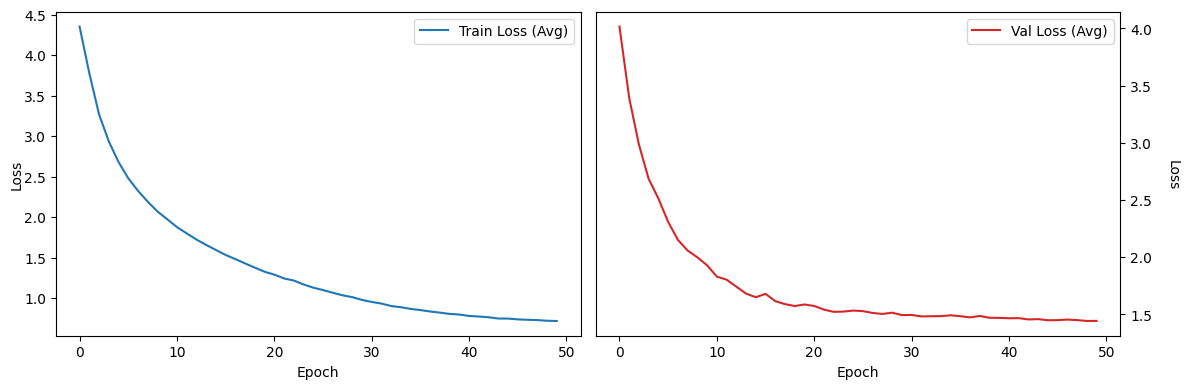

In [ ]:
# Average loss
plot_loss(
    train_history = train_history,
    val_history = val_history
)

## 11.2) Plot Summary Metrics

A **summary metric** refers to a metric that summarizes the model's overall performance across all classes in the dataset. Examples of summary metrics include accuracy, mean/min/max recall, mean/min/max precision, and mean/min/max F1-scores.

Summary metric curves (metric vs evaluation epoch) can be plotted using the `plot_results.plot_summary_metrics()` function. This function has 2 required arguments:
  - **val_history** (`ValHistory`): Validation-phase history object.
  - **metric_specs** (`Dict[str, MetricSpec]`): Dictionary mapping metric names to metric specifications. These specifications must produce a scalar value when extracting and processing from `val_history.metrics.values`.

<br>

In this example, the `metric_specs` argument is simply set to the `log_metric_specs` dictionary used during training. This means that we are plotting the same summary metrics that were displayed during logging.

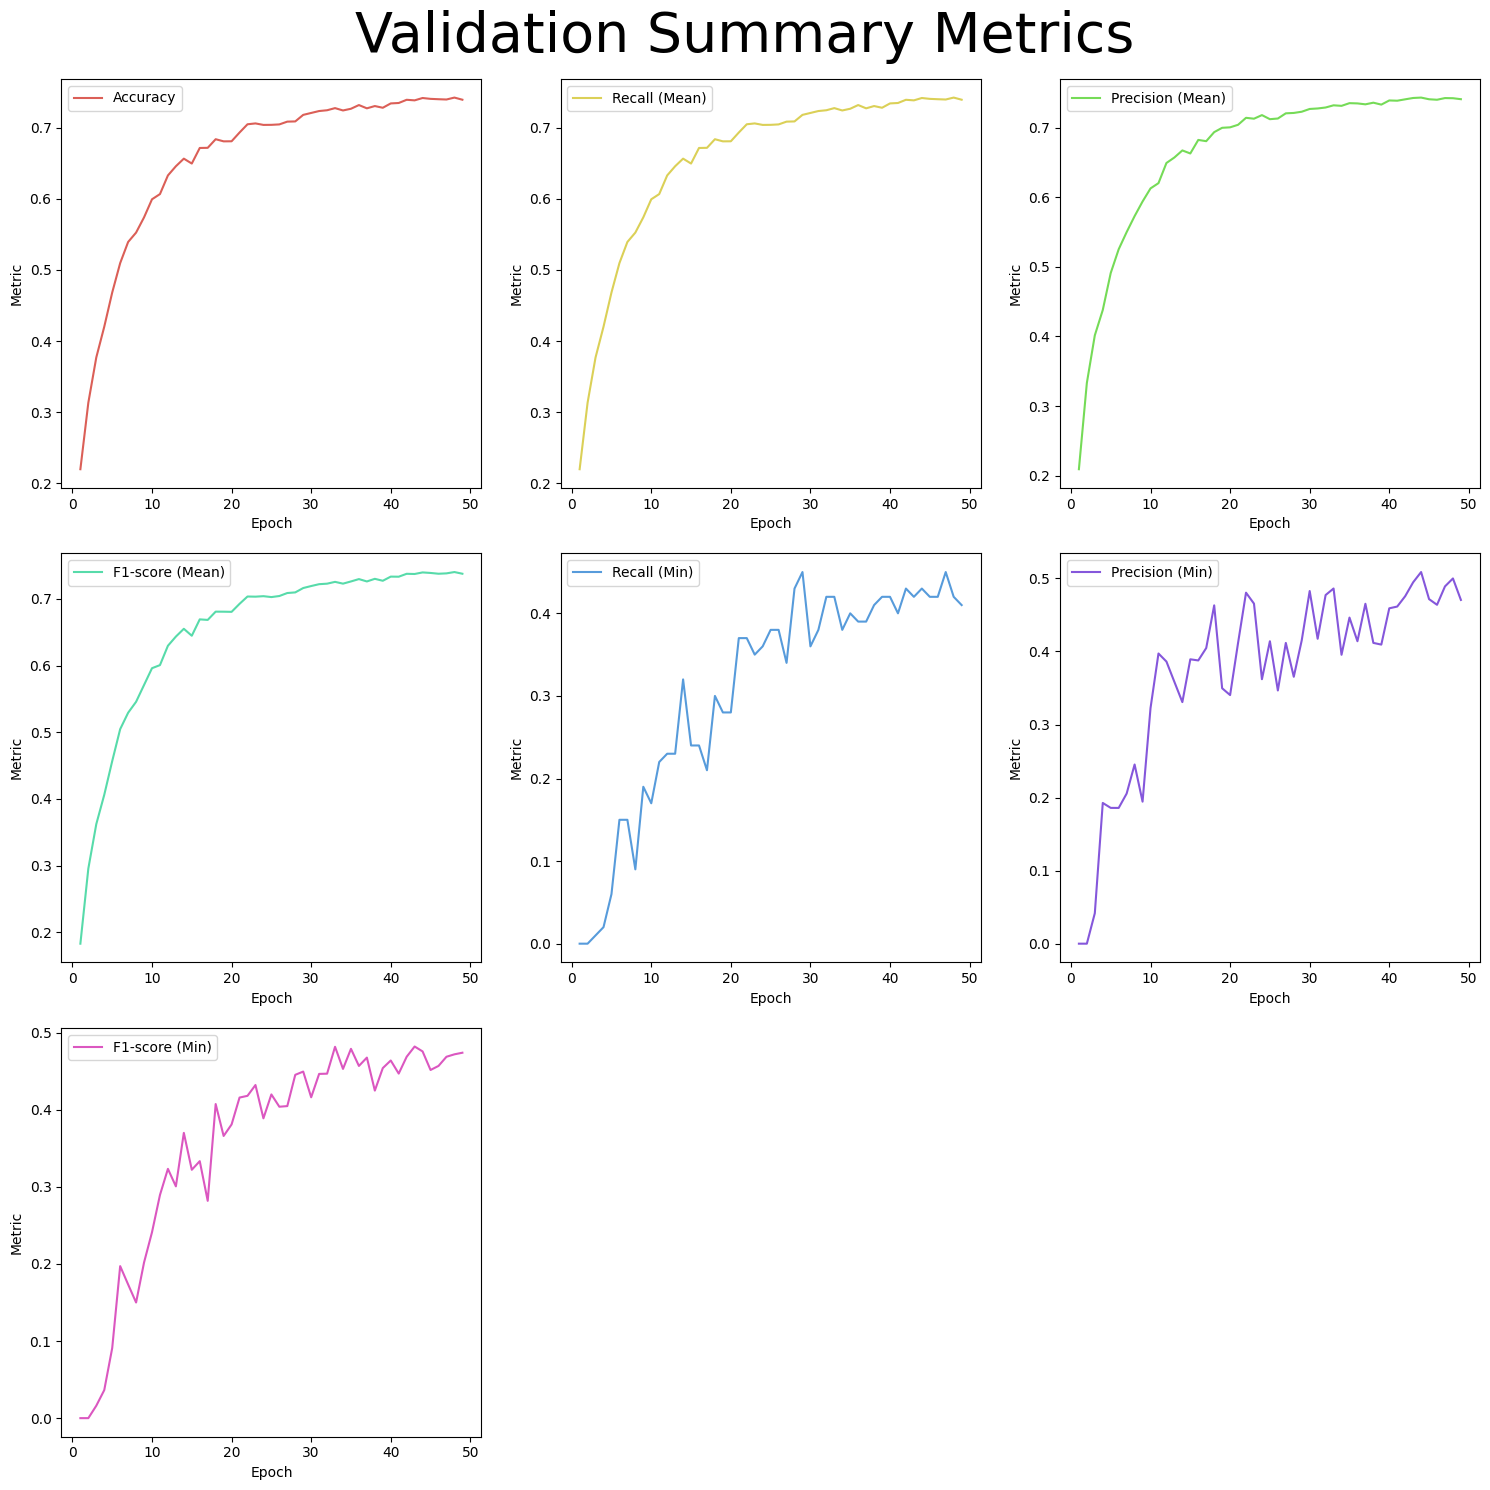

In [ ]:
# Summary metrics
plot_summary_metrics(
    val_history = val_history,
    metric_specs = log_metric_specs
)

## 11.3) Plot Class-Wise Metrics

A **class-wise metric** refers to a metric that measures the model's performance for each individual class in the dataset. When computed, class-wise metrics are generally returned as sequences of length `num_classes`, where each element corresponds to the metric value for the class at that index. Examples of class-wise metrics include recall, precision, and F1-score (all not aggregated).

Class-wise metric curves (metric vs evaluation epoch) can be plotted using the `plot_results.plot_class_metrics()` function. This function has the arguments:
  - **val_history** (`ValHistory`): Validation-phase history object.
  - **key_paths** (`List[str]`): List of dot-separated key paths within `val_history.metrics.values`. Each path must produce a sequence of class-wise tensors when extracting.
  - **class_names** (`List[str]`): List of class names.
  - **metric_labels** (optional, `List[str]`): Labels for the title of each class-wise metric subplot/panel. If not provided, the key paths in `key_paths` are used as titles.


The `plot_results.plot_class_metrics()` function will create a subplot for each class-wise metric in `key_paths`. Within each subplot, each class gets their own metric curve.

<br>

It is recommended to use this function only when there are a few classes in the dataset; otherwise, the subplots will appear very messy. Since the Mini-ImageNet dataset has 100 classes, we will not be plotting any class-wise metrics in this example.

In [ ]:
# # This is only recommended for datasets with a small number of classes
# key_paths = ['cls.recall','cls.precision','cls.f1_score']
# metric_labels = ['Recall', 'Precision', 'F1-score']

# # Class metrics
# plot_class_metrics(
#     val_history = val_history,
#     key_paths = key_paths,
#     class_names = val_dataset.class_names,
#     metric_labels = metric_labels
# )

# 12) Plot Predictions from Best Model


Image classification predictions for a list of images can be computed and plotted using the `plot_preds.plot_cls_preds()` function.

This function takes in the arguments:
  - **model** (`nn.Module`): Image classification model.
  - **imgs** (`Image(s)`): Images to predict on and plot. The supported input formats are:
    - A single PIL image
    - A single 3D tensor of shape (channels, height, width)
    - A list of images (each element is a PIL image or 3D tensor)
    - A batched 4D tensor of shape (batch_size, channels, height, width)
  - **class_names** (`List[str]`): List of class names.
  - **transforms** (optional, `v2.Compose`): Transforms used to preprocess the images before passing them into the model. If provided, this should be the same pipeline used during validation and it must produce tensors. If not provided, the images must already be tensors.
  - **targ_labels** (optional, `Label(s)`): Optional target labels for the images. If provided, these labels will be displayed on the plots and compared against the prediction labels. The supported input formats are:
    - A single integer
    - A single-element tensor
    - A list of labels (each element is an integer or single-element tensor)
    - A batched 1D tensor of shape (batch_size,)
  - **memory_format** (optional, `torch.memory_format`): Memory format to convert images to before predicting. If provided, this should ideally be the same memory format as the model. If not provided, no memory format conversion is applied.

<br>


  In this example, we randomly sample 10 images from the validation dataset.
  
  As explained in **2.2) Set up Datasets**, we use the `.get_base_item(index)` method of `val_dataset` to obtain the non-transformed sample images and the `.transform_pipeline` attribute to obtain the exact transform pipeline used during validation.

  

In [ ]:
# Get samples
num_samps = 10
samp_idxs = random.sample(range(len(val_dataset)), num_samps)

samps = [val_dataset.get_base_item(i) for i in samp_idxs]
imgs = [s['image'] for s in samps]
targ_labels = [s['label'] for s in samps]


# Plot predictions from best model
best_model.to('cpu') # Need to send model to CPU b/c images are on CPU

plot_preds.plot_cls_preds(
    model = best_model,
    imgs = imgs,
    class_names = val_dataset.class_names,
    transforms = val_dataset.transform_pipeline,
    targ_labels = targ_labels
)

Output hidden; open in https://colab.research.google.com to view.

# 13) (Optional) Download Saved Files from Google Colab

Instead of saving the full checkpoint file, the `engine.checkpoints.separate_checkpoint()` function can be used to split the checkpoint into multiple `.pth` files. Each file contains the saved state dictionary for a different checkpoint component (e.g. model, optimizer, scheduler, and history objects).

To **download all saved files** from this Google Colab example to out local machine, we first zip the save directory (`SAVE_DIR`) and then download the zipped file using `files.download()`.

In [ ]:
# # If needed, separate checkpoint into multiple .pth files
# separate_checkpoint(
#     checkpoint_path = save_settings.ckpt_path,
#     base_dir = SAVE_DIR
# )

In [ ]:
if IN_COLAB:
    from google.colab import files
    %cd /content/segformer-pytorch
    !zip -r backbone_pretrain.zip backbone_pretrain
    files.download('backbone_pretrain.zip')

/content/segformer-pytorch
  adding: backbone_pretrain/ (stored 0%)
  adding: backbone_pretrain/mini_imagenet/ (stored 0%)
  adding: backbone_pretrain/mini_imagenet/mit_b1/ (stored 0%)
  adding: backbone_pretrain/mini_imagenet/mit_b1/best_backbone.pth (deflated 7%)
  adding: backbone_pretrain/mini_imagenet/mit_b1/checkpoint.pth (deflated 8%)
  adding: backbone_pretrain/mini_imagenet/mit_b1/best_cls_mod.pth (deflated 7%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>